In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt


In [2]:
mutations_bc007 = pd.read_csv('../../4_figure_MPN_metrics/output/BC007_1_all_mutations.csv')

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


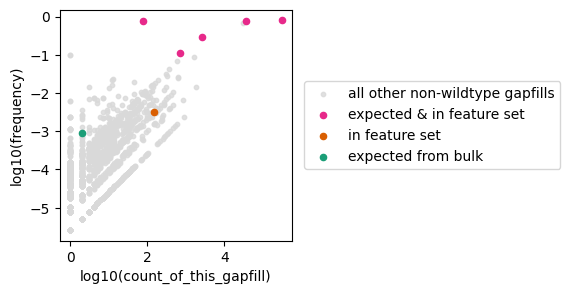

In [3]:
x = np.log10(mutations_bc007['count_of_this_gapfill'])
y = np.log10(mutations_bc007['frequency'])

expected = set(mutations_bc007.dropna(subset='expected_frequency_from_bulk')['HGVSc'].values)
in_fs = set(mutations_bc007.loc[mutations_bc007['in_feature_set']]['HGVSc'].values)
both = expected & in_fs

fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(x, y, s=10, color='#d9d9d9', alpha=0.8, label='all other non-wildtype gapfills')

s = 20
for subset, color, size, label in [
    (both, '#e7298a', s, 'expected & in feature set'),
    (in_fs - both, '#d95f02', s, 'in feature set'),
    (expected - both, '#1b9e77', s, 'expected from bulk')    
]:
    mask = mutations_bc007['HGVSc'].isin(subset)
    if mask.any():
        ax.scatter(
            np.log10(mutations_bc007.loc[mask, 'count_of_this_gapfill']),
            np.log10(mutations_bc007.loc[mask, 'frequency']),
            s=size, color=color, alpha=1, label=label,
        )

ax.set_xlabel('log10(count_of_this_gapfill)')
ax.set_ylabel('log10(frequency)')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.savefig('../plots/MPN_BC007_1_feature_set_scatter.pdf', bbox_inches='tight')
